In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
%cd /content
!rm -rf AI_safety_lab
!git clone https://github.com/MgSO4-7H2O/AI_safety_lab.git
%cd /content/AI_safety_lab/lab3
!pwd
!ls

/content
Cloning into 'AI_safety_lab'...
remote: Enumerating objects: 71853, done.
remote: Counting objects: 100% (71853/71853), done.
remote: Compressing objects: 100% (12791/12791), done.
remote: Total 71853 (delta 59059), reused 71853 (delta 59059), pack-reused 0 (from 0)
Receiving objects: 100% (71853/71853), 31.28 MiB | 34.93 MiB/s, done.
Resolving deltas: 100% (59059/59059), done.
Updating files: 100% (72723/72723), done.
/content/AI_safety_lab/lab3
/content/AI_safety_lab/lab3
client.py    figures  models.py  server.py
datasets.py  main.py  README.md  utils


In [6]:
!cat utils/conf.json

{
	
	"model_name" : "resnet18",
	
	"no_models" : 10,
	
	"type" : "cifar",
	
	"global_epochs" : 20,
	
	"local_epochs" : 3,
	
	"k" : 5,
	
	"batch_size" : 32,
	
	"lr" : 0.001,
	
	"momentum" : 0.0001,
	
	"lambda" : 0.1
}

In [7]:
import json
import os

quick_conf = {
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 1,
    "local_epochs": 1,
    "k": 3,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}

os.makedirs("utils", exist_ok=True)

with open("utils/conf_quick.json", "w") as f:
    json.dump(quick_conf, f, indent=4)

!cat utils/conf_quick.json

{
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 1,
    "local_epochs": 1,
    "k": 3,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}

In [8]:
!python main.py -c ./utils/conf_quick.json

100% 170M/170M [00:06<00:00, 24.4MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 0 done.
Epoch 0 done.
Epoch 0 done.
Epoch 0, acc: 0.370000, loss: 7.970607



In [9]:
import copy
import random
import json
import os
import pandas as pd
import torch
import torch.nn as nn

from server import Server
from client import Client
import datasets

def fix_model_for_cifar10(model):
    """
    将 torchvision 模型的最后分类层改成 CIFAR-10 的 10 类输出。
    """
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 10)

    elif hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, 10)

    if torch.cuda.is_available():
        model = model.cuda()

    return model


def run_federated_experiment(conf, exp_name, seed=42):
    """
    按 lab3 原始 main.py 的逻辑运行联邦学习实验，并保存每轮 acc/loss。
    修正点：
    1. server.global_model 改为 CIFAR-10 的 10 类输出；
    2. 每个 client.local_model 也改为 CIFAR-10 的 10 类输出。
    """

    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    os.makedirs("results", exist_ok=True)

    print("=" * 60)
    print("Experiment:", exp_name)
    print("Config:")
    print(json.dumps(conf, indent=4))
    print("=" * 60)

    train_dataset, eval_dataset = datasets.get_dataset("./data/", conf["type"])

    # 创建 server，并修正 server 的全局模型输出层
    server = Server(conf, eval_dataset)
    server.global_model = fix_model_for_cifar10(server.global_model)

    print("Server final layer:")
    if hasattr(server.global_model, "fc"):
        print(server.global_model.fc)
    elif hasattr(server.global_model, "classifier"):
        print(server.global_model.classifier)

    # 创建 clients，并修正每个 client 的本地模型输出层
    clients = []
    for c in range(conf["no_models"]):
        client = Client(conf, server.global_model, train_dataset, c)
        client.local_model = fix_model_for_cifar10(client.local_model)
        clients.append(client)

    print("Client final layer example:")
    if hasattr(clients[0].local_model, "fc"):
        print(clients[0].local_model.fc)
    elif hasattr(clients[0].local_model, "classifier"):
        print(clients[0].local_model.classifier)

    history = []

    for e in range(conf["global_epochs"]):
        print(f"\nGlobal Epoch {e + 1}/{conf['global_epochs']}")

        candidates = random.sample(clients, conf["k"])
        selected_client_ids = [c.client_id for c in candidates]
        print("Selected clients:", selected_client_ids)

        weight_accumulator = {}

        for name, params in server.global_model.state_dict().items():
            weight_accumulator[name] = torch.zeros_like(params)

        for c in candidates:
            print(f"Client {c.client_id} local training...")
            diff = c.local_train(server.global_model)

            for name, params in server.global_model.state_dict().items():
                weight_accumulator[name].add_(diff[name])

        server.model_aggregate(weight_accumulator)

        acc, loss = server.model_eval()

        print(f"Global Epoch {e + 1}, acc: {acc:.4f}, loss: {loss:.4f}")

        history.append({
            "experiment": exp_name,
            "global_epoch": e + 1,
            "k": conf["k"],
            "no_models": conf["no_models"],
            "local_epochs": conf["local_epochs"],
            "lambda": conf["lambda"],
            "lr": conf["lr"],
            "accuracy": acc,
            "loss": loss,
            "selected_clients": str(selected_client_ids)
        })

    history_df = pd.DataFrame(history)

    csv_path = f"results/{exp_name}_history.csv"
    history_df.to_csv(csv_path, index=False)

    print("\nSaved history to:", csv_path)

    return history_df

print("Fixed run_federated_experiment defined.")

Fixed run_federated_experiment defined.


In [10]:
conf_test = {
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 2,
    "local_epochs": 1,
    "k": 3,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}

hist_test = run_federated_experiment(
    conf=conf_test,
    exp_name="test_k3_ge2_le1_fixed_fc",
    seed=42
)

hist_test

Experiment: test_k3_ge2_le1_fixed_fc
Config:
{
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 2,
    "local_epochs": 1,
    "k": 3,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Server final layer:
Linear(in_features=512, out_features=10, bias=True)
Client final layer example:
Linear(in_features=512, out_features=10, bias=True)

Global Epoch 1/2
Selected clients: [1, 0, 4]
Client 1 local training...
Epoch 0 done.
Client 0 local training...
Epoch 0 done.
Client 4 local training...
Epoch 0 done.
Global Epoch 1, acc: 14.3100, loss: 2.2999

Global Epoch 2/2
Selected clients: [3, 9, 2]
Client 3 local training...
Epoch 0 done.
Client 9 local training...
Epoch 0 done.
Client 2 local training...
Epoch 0 done.
Global Epoch 2, acc: 19.7300, loss: 2.1765

Saved history to: results/test_k3_ge2_le1_fixed_fc_history.csv


,experiment,global_epoch,k,no_models,local_epochs,lambda,lr,accuracy,loss,selected_clients
0,test_k3_ge2_le1_fixed_fc,1,3,10,1,0.1,0.001,14.31,2.299935,"[1, 0, 4]"
1,test_k3_ge2_le1_fixed_fc,2,3,10,1,0.1,0.001,19.73,2.176451,"[3, 9, 2]"


In [11]:
conf_k3 = {
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 10,
    "local_epochs": 1,
    "k": 3,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}

hist_k3 = run_federated_experiment(
    conf=conf_k3,
    exp_name="fedavg_k3_ge10_le1_fixed_fc",
    seed=42
)

hist_k3

Experiment: fedavg_k3_ge10_le1_fixed_fc
Config:
{
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 10,
    "local_epochs": 1,
    "k": 3,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Server final layer:
Linear(in_features=512, out_features=10, bias=True)
Client final layer example:
Linear(in_features=512, out_features=10, bias=True)

Global Epoch 1/10
Selected clients: [1, 0, 4]
Client 1 local training...
Epoch 0 done.
Client 0 local training...
Epoch 0 done.
Client 4 local training...
Epoch 0 done.
Global Epoch 1, acc: 14.3100, loss: 2.2996

Global Epoch 2/10
Selected clients: [3, 9, 2]
Client 3 local training...
Epoch 0 done.
Client 9 local training...
Epoch 0 done.
Client 2 local training...
Epoch 0 done.
Global Epoch 2, acc: 19.8200, loss: 2.1762

Global Epoch 3/10
Selected clients: [1, 8, 9]
Client 1 local training...
Epoch 0 done.
Client 8 local training...
Epoch 0 done.
Client 9 local training...
Epoch 0 done.
Global Epoch 3, acc: 26.5300, loss: 2.0721

Global Epoch 4/10
Selected clients: [9, 6, 0]
Client 9 local training...
Epoch 0 done.
Client 6 local training...
Epoch 0 done.
Client 0 local training...
Epoch 0 done.
Global Epoch 4, acc: 32.8600, loss: 1.9

,experiment,global_epoch,k,no_models,local_epochs,lambda,lr,accuracy,loss,selected_clients
0,fedavg_k3_ge10_le1_fixed_fc,1,3,10,1,0.1,0.001,14.31,2.299608,"[1, 0, 4]"
1,fedavg_k3_ge10_le1_fixed_fc,2,3,10,1,0.1,0.001,19.82,2.176221,"[3, 9, 2]"
2,fedavg_k3_ge10_le1_fixed_fc,3,3,10,1,0.1,0.001,26.53,2.072054,"[1, 8, 9]"
3,fedavg_k3_ge10_le1_fixed_fc,4,3,10,1,0.1,0.001,32.86,1.970995,"[9, 6, 0]"
4,fedavg_k3_ge10_le1_fixed_fc,5,3,10,1,0.1,0.001,37.46,1.879843,"[0, 1, 3]"
5,fedavg_k3_ge10_le1_fixed_fc,6,3,10,1,0.1,0.001,40.23,1.797929,"[3, 8, 0]"
6,fedavg_k3_ge10_le1_fixed_fc,7,3,10,1,0.1,0.001,42.28,1.730059,"[8, 3, 6]"
7,fedavg_k3_ge10_le1_fixed_fc,8,3,10,1,0.1,0.001,43.50,1.673433,"[3, 7, 4]"
8,fedavg_k3_ge10_le1_fixed_fc,9,3,10,1,0.1,0.001,44.43,1.625865,"[0, 2, 6]"
9,fedavg_k3_ge10_le1_fixed_fc,10,3,10,1,0.1,0.001,45.70,1.579267,"[5, 4, 2]"


In [12]:
conf_k5 = {
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 10,
    "local_epochs": 1,
    "k": 5,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}

hist_k5 = run_federated_experiment(
    conf=conf_k5,
    exp_name="fedavg_k5_ge10_le1_fixed_fc",
    seed=42
)

hist_k5

Experiment: fedavg_k5_ge10_le1_fixed_fc
Config:
{
    "model_name": "resnet18",
    "no_models": 10,
    "type": "cifar",
    "global_epochs": 10,
    "local_epochs": 1,
    "k": 5,
    "batch_size": 32,
    "lr": 0.001,
    "momentum": 0.0001,
    "lambda": 0.1
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Server final layer:
Linear(in_features=512, out_features=10, bias=True)
Client final layer example:
Linear(in_features=512, out_features=10, bias=True)

Global Epoch 1/10
Selected clients: [1, 0, 4, 9, 6]
Client 1 local training...
Epoch 0 done.
Client 0 local training...
Epoch 0 done.
Client 4 local training...
Epoch 0 done.
Client 9 local training...
Epoch 0 done.
Client 6 local training...
Epoch 0 done.
Global Epoch 1, acc: 18.5600, loss: 2.1977

Global Epoch 2/10
Selected clients: [2, 1, 8, 4, 3]
Client 2 local training...
Epoch 0 done.
Client 1 local training...
Epoch 0 done.
Client 8 local training...
Epoch 0 done.
Client 4 local training...
Epoch 0 done.
Client 3 local training...
Epoch 0 done.
Global Epoch 2, acc: 30.5400, loss: 2.0114

Global Epoch 3/10
Selected clients: [0, 9, 1, 7, 6]
Client 0 local training...
Epoch 0 done.
Client 9 local training...
Epoch 0 done.
Client 1 local training...
Epoch 0 done.
Client 7 local training...
Epoch 0 done.
Client 6 local training...
Ep

,experiment,global_epoch,k,no_models,local_epochs,lambda,lr,accuracy,loss,selected_clients
0,fedavg_k5_ge10_le1_fixed_fc,1,5,10,1,0.1,0.001,18.56,2.197680,"[1, 0, 4, 9, 6]"
1,fedavg_k5_ge10_le1_fixed_fc,2,5,10,1,0.1,0.001,30.54,2.011396,"[2, 1, 8, 4, 3]"
2,fedavg_k5_ge10_le1_fixed_fc,3,5,10,1,0.1,0.001,38.25,1.852869,"[0, 9, 1, 7, 6]"
3,fedavg_k5_ge10_le1_fixed_fc,4,5,10,1,0.1,0.001,41.42,1.734096,"[8, 0, 3, 5, 6]"
4,fedavg_k5_ge10_le1_fixed_fc,5,5,10,1,0.1,0.001,43.03,1.647546,"[8, 6, 3, 7, 4]"
5,fedavg_k5_ge10_le1_fixed_fc,6,5,10,1,0.1,0.001,45.20,1.577810,"[4, 0, 2, 5, 3]"
6,fedavg_k5_ge10_le1_fixed_fc,7,5,10,1,0.1,0.001,46.78,1.519994,"[5, 4, 2, 1, 7]"
7,fedavg_k5_ge10_le1_fixed_fc,8,5,10,1,0.1,0.001,48.43,1.474094,"[1, 9, 6, 0, 2]"
8,fedavg_k5_ge10_le1_fixed_fc,9,5,10,1,0.1,0.001,50.01,1.434851,"[5, 4, 0, 9, 3]"
9,fedavg_k5_ge10_le1_fixed_fc,10,5,10,1,0.1,0.001,50.87,1.399670,"[8, 1, 6, 0, 4]"


In [13]:
!find results -maxdepth 1 -type f | sort

results/fedavg_k3_ge10_le1_fixed_fc_history.csv
results/fedavg_k5_ge10_le1_fixed_fc_history.csv
results/test_k3_ge2_le1_fixed_fc_history.csv


In [14]:
import pandas as pd
import os

hist_k3 = pd.read_csv("results/fedavg_k3_ge10_le1_fixed_fc_history.csv")
hist_k5 = pd.read_csv("results/fedavg_k5_ge10_le1_fixed_fc_history.csv")

all_history = pd.concat([hist_k3, hist_k5], ignore_index=True)

all_history.to_csv("results/lab3_all_history.csv", index=False)

all_history

,experiment,global_epoch,k,no_models,local_epochs,lambda,lr,accuracy,loss,selected_clients
0,fedavg_k3_ge10_le1_fixed_fc,1,3,10,1,0.1,0.001,14.31,2.299608,"[1, 0, 4]"
1,fedavg_k3_ge10_le1_fixed_fc,2,3,10,1,0.1,0.001,19.82,2.176221,"[3, 9, 2]"
2,fedavg_k3_ge10_le1_fixed_fc,3,3,10,1,0.1,0.001,26.53,2.072054,"[1, 8, 9]"
3,fedavg_k3_ge10_le1_fixed_fc,4,3,10,1,0.1,0.001,32.86,1.970995,"[9, 6, 0]"
4,fedavg_k3_ge10_le1_fixed_fc,5,3,10,1,0.1,0.001,37.46,1.879843,"[0, 1, 3]"
5,fedavg_k3_ge10_le1_fixed_fc,6,3,10,1,0.1,0.001,40.23,1.797929,"[3, 8, 0]"
6,fedavg_k3_ge10_le1_fixed_fc,7,3,10,1,0.1,0.001,42.28,1.730059,"[8, 3, 6]"
7,fedavg_k3_ge10_le1_fixed_fc,8,3,10,1,0.1,0.001,43.50,1.673433,"[3, 7, 4]"
8,fedavg_k3_ge10_le1_fixed_fc,9,3,10,1,0.1,0.001,44.43,1.625865,"[0, 2, 6]"
9,fedavg_k3_ge10_le1_fixed_fc,10,3,10,1,0.1,0.001,45.70,1.579267,"[5, 4, 2]"


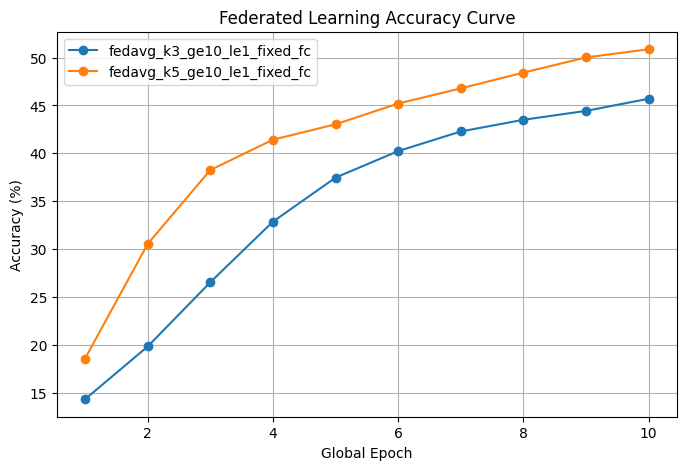

Saved to results/lab3_accuracy_curve.png


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for exp_name, group in all_history.groupby("experiment"):
    plt.plot(
        group["global_epoch"],
        group["accuracy"],
        marker="o",
        label=exp_name
    )

plt.xlabel("Global Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Federated Learning Accuracy Curve")
plt.legend()
plt.grid(True)

plt.savefig("results/lab3_accuracy_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved to results/lab3_accuracy_curve.png")

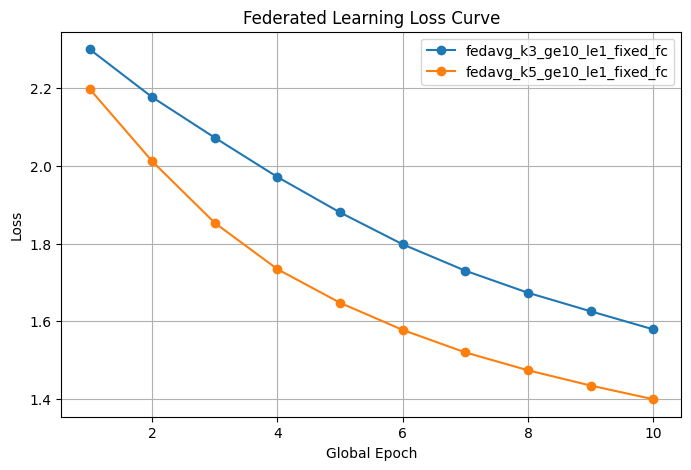

Saved to results/lab3_loss_curve.png


In [16]:
plt.figure(figsize=(8, 5))

for exp_name, group in all_history.groupby("experiment"):
    plt.plot(
        group["global_epoch"],
        group["loss"],
        marker="o",
        label=exp_name
    )

plt.xlabel("Global Epoch")
plt.ylabel("Loss")
plt.title("Federated Learning Loss Curve")
plt.legend()
plt.grid(True)

plt.savefig("results/lab3_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved to results/lab3_loss_curve.png")

In [17]:
summary_table = all_history.groupby("experiment").agg(
    final_accuracy=("accuracy", "last"),
    best_accuracy=("accuracy", "max"),
    final_loss=("loss", "last"),
    min_loss=("loss", "min"),
    global_epochs=("global_epoch", "max"),
    k=("k", "first"),
    local_epochs=("local_epochs", "first"),
    lambda_value=("lambda", "first"),
    lr=("lr", "first")
).reset_index()

summary_table.to_csv("results/lab3_summary_table.csv", index=False)

summary_table

,experiment,final_accuracy,best_accuracy,final_loss,min_loss,global_epochs,k,local_epochs,lambda_value,lr
0,fedavg_k3_ge10_le1_fixed_fc,45.70,45.70,1.579267,1.579267,10,3,1,0.1,0.001
1,fedavg_k5_ge10_le1_fixed_fc,50.87,50.87,1.399670,1.399670,10,5,1,0.1,0.001


In [18]:
report_table = summary_table.copy()

report_table["配置说明"] = report_table["k"].apply(
    lambda x: f"每轮选择 {x} 个客户端参与聚合"
)

report_table = report_table[
    [
        "experiment",
        "配置说明",
        "k",
        "global_epochs",
        "local_epochs",
        "lambda_value",
        "lr",
        "final_accuracy",
        "best_accuracy",
        "final_loss",
        "min_loss"
    ]
]

report_table = report_table.rename(columns={
    "experiment": "实验名称",
    "k": "每轮参与客户端数 k",
    "global_epochs": "全局训练轮数",
    "local_epochs": "本地训练轮数",
    "lambda_value": "聚合系数 lambda",
    "lr": "学习率",
    "final_accuracy": "最终准确率(%)",
    "best_accuracy": "最佳准确率(%)",
    "final_loss": "最终损失",
    "min_loss": "最小损失"
})

report_table.to_csv("results/lab3_report_table.csv", index=False)

report_table

,实验名称,配置说明,每轮参与客户端数 k,全局训练轮数,本地训练轮数,聚合系数 lambda,学习率,最终准确率(%),最佳准确率(%),最终损失,最小损失
0,fedavg_k3_ge10_le1_fixed_fc,每轮选择 3 个客户端参与聚合,3,10,1,0.1,0.001,45.70,45.70,1.579267,1.579267
1,fedavg_k5_ge10_le1_fixed_fc,每轮选择 5 个客户端参与聚合,5,10,1,0.1,0.001,50.87,50.87,1.399670,1.399670


In [19]:
import json

experiment_notes = {
    "experiment_goal": "Compare the effect of different k values in federated learning.",
    "dataset": "CIFAR-10",
    "model": "ResNet18 with final fc layer changed to 10 classes",
    "federated_algorithm": "FedAvg-style aggregation",
    "client_number": 10,
    "compared_settings": [
        {
            "name": "fedavg_k3_ge10_le1_fixed_fc",
            "k": 3,
            "global_epochs": 10,
            "local_epochs": 1
        },
        {
            "name": "fedavg_k5_ge10_le1_fixed_fc",
            "k": 5,
            "global_epochs": 10,
            "local_epochs": 1
        }
    ],
    "important_fix": "The original torchvision ResNet18 output layer is for 1000 ImageNet classes. It was changed to Linear(512, 10) for CIFAR-10."
}

with open("results/lab3_experiment_notes.json", "w", encoding="utf-8") as f:
    json.dump(experiment_notes, f, indent=4, ensure_ascii=False)

print("Saved to results/lab3_experiment_notes.json")

Saved to results/lab3_experiment_notes.json


In [20]:
!find results -maxdepth 1 -type f | sort

results/fedavg_k3_ge10_le1_fixed_fc_history.csv
results/fedavg_k5_ge10_le1_fixed_fc_history.csv
results/lab3_accuracy_curve.png
results/lab3_all_history.csv
results/lab3_experiment_notes.json
results/lab3_loss_curve.png
results/lab3_report_table.csv
results/lab3_summary_table.csv
results/test_k3_ge2_le1_fixed_fc_history.csv


In [21]:
!zip -r lab3_results.zip results

  adding: results/ (stored 0%)
  adding: results/lab3_summary_table.csv (deflated 49%)
  adding: results/fedavg_k5_ge10_le1_fixed_fc_history.csv (deflated 63%)
  adding: results/test_k3_ge2_le1_fixed_fc_history.csv (deflated 35%)
  adding: results/lab3_accuracy_curve.png (deflated 10%)
  adding: results/lab3_report_table.csv (deflated 41%)
  adding: results/lab3_experiment_notes.json (deflated 53%)
  adding: results/fedavg_k3_ge10_le1_fixed_fc_history.csv (deflated 62%)
  adding: results/lab3_all_history.csv (deflated 68%)
  adding: results/lab3_loss_curve.png (deflated 9%)
